# Skill 5: API Search - Make our bot to talk to any API

We have observed the remarkable synergy created by combining **OpenAI llms with intelligent agents and detailed prompts**. This powerful combination has consistently delivered impressive results. To further capitalize on this capability, we should aim to integrate it with various systems through API communication. Essentially, we can develop within this notebook what is referred to in OpenAI's ChatGPT as 'GPTs.'

Envision a bot that seamlessly integrates with:

- **CRM Systems:** Including Dynamics, Salesforce, and HubSpot.
- **ERP Systems:** Such as SAP, Dynamics, and Oracle.
- **CMS Systems:** Including Adobe, Oracle, and other content management platforms.

The objective is to connect our bot with data repositories, minimizing data duplication as much as possible. These systems typically offer APIs, facilitating programmatic data access.

In this notebook, we plan to develop an agent capable of querying an API to retrieve information and effectively answer questions.
This time we are going to use an open API for currency and digital coins pricing: https://docs.kraken.com/rest/#tag/Market-Data

In [1]:
import os
import json
import requests
from pydantic import BaseModel 

from langchain_openai import AzureChatOpenAI
from langchain_core.tools import BaseTool, StructuredTool
from langchain_community.agent_toolkits.openapi.toolkit import RequestsToolkit
from langchain_community.utilities.requests import RequestsWrapper, TextRequestsWrapper

from langgraph.prebuilt import create_react_agent

from common.utils import num_tokens_from_string, reduce_openapi_spec
from common.prompts import APISEARCH_PROMPT_TEXT

from IPython.display import Markdown, HTML, display  

from dotenv import load_dotenv
load_dotenv("credentials.env")

def printmd(string):
    display(Markdown(string.replace("$","USD ")))

    
QUESTION_BITCOIN = """
Tell me the price of bitcoin against USD , also the latest OHLC values for Ethereum,
also tell me the bid and ask for Euro.
"""

QUESTION_SANDISK = 'what is the price for SanDisk "memory cards"? give me the links please'

QUESTION_WEATHER = "Che tempo fa a Chiavari?"

In [2]:
# Set the ENV variables that Langchain needs to connect to Azure OpenAI
os.environ["OPENAI_API_VERSION"] = os.environ["AZURE_OPENAI_API_VERSION"]

In [3]:
COMPLETION_TOKENS = 2000

# This notebook needs GPT-4-Turbo (context size of 128k tokens)
llm = AzureChatOpenAI(
    deployment_name=os.environ["GPT4o_DEPLOYMENT_NAME"], 
    temperature=0.5, 
    max_tokens=COMPLETION_TOKENS, 
    streaming=True)

## The Logic

By now, you must infer that the solution for an API Agent has to be something like: give the API specification as part of the system prompt to the LLM , then let a graph agent plan for the right steps to formulate the API calls.<br>

Let's do that. But we must first understand the industry standards of Swagger/OpenAPI


## Introduction to OpenAPI (formerly Swagger)

The OpenAPI Specification, previously known as the Swagger Specification, is a specification for a machine-readable interface definition language for describing, producing, consuming and visualizing web services. Previously part of the Swagger framework, it became a separate project in 2016, overseen by the OpenAPI Initiative, an open-source collaboration project of the Linux Foundation.

OpenAPI Specification is an API description format for REST APIs. An OpenAPI file allows you to describe your entire API, including: Available endpoints (/users for example) and operations on each endpoint ( GET /users, POST /users), description, contact information, license, terms of use and other information.

### Let's get the OpenAPI (Swagger) spec from our desired API that we want to talk to
You can also download it from the Kraken website: https://docs.kraken.com/rest/

### In Italian
Kraken è una piattaforma di scambio di criptovalute che offre diverse API per l'integrazione e l'automazione delle operazioni di trading. Il portale Kraken API Center fornisce documentazione dettagliata sulle API disponibili, tra cui **REST API**, utilizzate per richieste e risposte HTTP, ideale per operazioni di trading e gestione degli account.<br/><br/>

Kraken offre un **ambiente di test API** separato dal sistema di produzione, ideale per sviluppatori che vogliono sperimentare con le OpenAPI senza rischiare fondi reali. L'area di test è accessibile senza credenziali di un account reale. Occorre comunque registrarsi e generare chiavi API per simulare operazioni di trading.<br/>- 
Le API usate nel sistema di test sono identiche a quelle Live: Le API REST e WebSocket nel sistema demo funzionano esattamente come quelle della piattaforma di produzione, permettendoti di testare chiamate e risposte senza impatti finanziari.
- Documentazione ufficiale: https://docs.kraken.com/api/
- Abiente di test: https://support.kraken.com/hc/it-it/articles/360024809011-api-testing-environment-derivatives

Let's see how big is this API specification:

In [4]:
LOCAL_FILE_PATH = "./data/openapi_kraken.json" # ./data/openapi_kraken.json or ./data/weather_openapi.json

# Open and read the JSON file
with open(LOCAL_FILE_PATH, 'r') as file:
    spec = json.load(file)
    
display(spec)

{'openapi': '3.0.0',
 'servers': [{'url': 'https://api.kraken.com/0',
   'description': 'Production Server'}],
 'info': {'title': 'REST API',
  'version': '1.1.0',
  'x-logo': {'url': 'kraken_logo_w.png', 'altText': 'Kraken Logo'},
  'description': '# General Usage\nThis document details use of Kraken\'s REST API for our Spot exchange. The Spot exchange [Websockets API](https://docs.kraken.com/websockets) and the [Kraken Futures APIs](https://docs.futures.kraken.com/) are documented separately. Our REST API is organised into publicly accessible endpoints (market data, exchange status, etc.), and private authenticated endpoints (trading, funding, user data) which require requests to be signed.\n\nYour use of the Kraken REST API is subject to the [Kraken Terms & Conditions](https://www.kraken.com/legal), [Privacy Notice](http://www.kraken.com/legal/privacy), as well as all other applicable terms and disclosures made available on [www.kraken.com](http://www.kraken.com/).\n\n## Support\nFu

In [5]:
# You can check the function "reduce_openapi_spec()" in utils.py
reduced_api_spec = reduce_openapi_spec(spec)

api_tokens = num_tokens_from_string(str(spec))
print("API spec size in tokens:",api_tokens)
api_tokens = num_tokens_from_string(str(reduced_api_spec))
print("Reduced API spec size in tokens:",api_tokens)

reduced_api_spec

API spec size in tokens: 66625
Reduced API spec size in tokens: 57394


ReducedOpenAPISpec(servers=[{'url': 'https://api.kraken.com/0', 'description': 'Production Server'}], description='# General Usage\nThis document details use of Kraken\'s REST API for our Spot exchange. The Spot exchange [Websockets API](https://docs.kraken.com/websockets) and the [Kraken Futures APIs](https://docs.futures.kraken.com/) are documented separately. Our REST API is organised into publicly accessible endpoints (market data, exchange status, etc.), and private authenticated endpoints (trading, funding, user data) which require requests to be signed.\n\nYour use of the Kraken REST API is subject to the [Kraken Terms & Conditions](https://www.kraken.com/legal), [Privacy Notice](http://www.kraken.com/legal/privacy), as well as all other applicable terms and disclosures made available on [www.kraken.com](http://www.kraken.com/).\n\n## Support\nFurther information and FAQs may be found on the [API section](https://support.kraken.com/hc/en-us/sections/4402371110548-API) of our sup

Sometimes it makes sense to reduce the size of the API Specs by using the `reduce_openapi_spec` function. It's optional.

#### NOTE: As you can see, a large context LLM is needed. `GPT4` or newer models are necessary for this notebook to run succesfully.

### Define the `Toolkit`, e.g. the Tools Container

In [6]:
# Most of APIs require Authorization tokens, so we construct the headers using a lightweight python request wrapper called RequestsWrapper
access_token = "ABCDEFG123456" 
headers = {"Authorization": f"Bearer {access_token}"}
requests_wrapper = RequestsWrapper(headers=headers)

toolkit = RequestsToolkit(
    requests_wrapper=RequestsWrapper(headers=headers),
    allow_dangerous_requests=True,
)

tools = toolkit.get_tools()
tools

[RequestsGetTool(requests_wrapper=TextRequestsWrapper(headers={'Authorization': 'Bearer ABCDEFG123456'}, aiosession=None, auth=None, response_content_type='text', verify=True), allow_dangerous_requests=True),
 RequestsPostTool(requests_wrapper=TextRequestsWrapper(headers={'Authorization': 'Bearer ABCDEFG123456'}, aiosession=None, auth=None, response_content_type='text', verify=True), allow_dangerous_requests=True),
 RequestsPatchTool(requests_wrapper=TextRequestsWrapper(headers={'Authorization': 'Bearer ABCDEFG123456'}, aiosession=None, auth=None, response_content_type='text', verify=True), allow_dangerous_requests=True),
 RequestsPutTool(requests_wrapper=TextRequestsWrapper(headers={'Authorization': 'Bearer ABCDEFG123456'}, aiosession=None, auth=None, response_content_type='text', verify=True), allow_dangerous_requests=True),
 RequestsDeleteTool(requests_wrapper=TextRequestsWrapper(headers={'Authorization': 'Bearer ABCDEFG123456'}, aiosession=None, auth=None, response_content_type='te

### Define Prompt

In [7]:
print(APISEARCH_PROMPT_TEXT)



## Source of Information
- You have access to an API to help answer user queries.
- Here is documentation on the API: {api_spec}

## On how to use the Tools
- You are an agent designed to connect to RestFul APIs.
- Given API documentation above, use the right tools to connect to the API.
- **ALWAYS** before giving the Final Answer, try another method if available. Then reflect on the answers of the two methods you did and ask yourself if it answers correctly the original question. If you are not sure, try another method.
- If you are sure of the correct answer, create a beautiful and thorough response using Markdown.
- **DO NOT MAKE UP AN ANSWER OR USE Pre-Existing KNOWLEDGE, ONLY USE THE RESULTS OF THE CALCULATIONS YOU HAVE DONE**. 
- Only use the output of your code to answer the question. 



### Create Graph

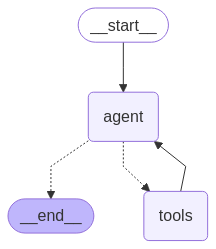

In [8]:
graph = create_react_agent(llm, tools, state_modifier=APISEARCH_PROMPT_TEXT.format(api_spec=reduced_api_spec))
graph

### Helper function to print the graph content

In [9]:
async def stream_graph_updates_async(graph, user_input: str):
    inputs = {"messages": [("human", user_input)]}

    async for event in graph.astream_events(inputs, version="v2"):
        if (event["event"] == "on_chat_model_stream"):
            # Print the content of the chunk progressively
            print(event["data"]["chunk"].content, end="", flush=True)
        elif (event["event"] == "on_tool_start"  ):
            print("\n--")
            print(f"Calling tool: {event['name']} with inputs: {event['data'].get('input')}")
            print("--")

### Run the Graph

In [10]:
await stream_graph_updates_async(graph, QUESTION_BITCOIN)


--
Calling tool: requests_get with inputs: {'url': 'https://api.kraken.com/0/public/Ticker?pair=XXBTZUSD'}
--

--
Calling tool: requests_get with inputs: {'url': 'https://api.kraken.com/0/public/OHLC?pair=XETHZUSD'}
--

--
Calling tool: requests_get with inputs: {'url': 'https://api.kraken.com/0/public/Depth?pair=ZEURZUSD'}
--
### Bitcoin Price Against USD
- **Price**: $103,396.40

### Latest OHLC Values for Ethereum (ETH/USD)
The latest OHLC (Open/High/Low/Close) values for Ethereum against USD are:

- **Open**: $2523.21
- **High**: $2527.91
- **Low**: $2523.21
- **Close**: $2523.58

These values are based on the most recent data from the Kraken exchange.

### Bid and Ask for Euro (EUR/USD)
Here are the current bid and ask prices for Euro against USD:

- **Bid**: $1.11221
- **Ask**: $1.11228

These values reflect the current order book entries for the EUR/USD pair on the Kraken exchange.

**Great!!** we have now an API Agent, capable of reasoning until it can find the answer given an API documentation.

# Simple APIs

What happens if the API is quite basic, meaning it's just a simple endpoint without a Swagger/OpenAPI definition?

## Simple API #1: [CountdownAPI](https://www.countdownapi.com/)
`[CountdownAPI]` is a streamlined version of the eBay API, available as a paid service. We can test it using their demo query, which does not require any Swagger or OpenAPI specification. In this scenario, our main task is to create a tool that retrieves the results. We then pass these results to an agent for analysis, providing answers to user queries, similar to our approach with the Bing Search agent.

In the example below, there is no API specification, but the response from the API is rather lengthy.

In [11]:
# set up the request parameters
params = {
  'api_key': 'demo',
  'type': 'search',
  'ebay_domain': 'ebay.com',
  'search_term': QUESTION_SANDISK
}

# make the http GET request to Countdown API
api_result = requests.get('https://api.countdownapi.com/request', params)

num_tokens = num_tokens_from_string(str(api_result.json())) # this is a custom function we created in common/utils.py
print("Token count:",num_tokens,"\n")  

# print the first 2000 characters of JSON response from Countdown API
print(json.dumps(api_result.json())[:2000], "...")

Token count: 12775 

{"request_info": {"success": true, "demo": true}, "request_parameters": {"type": "search", "ebay_domain": "ebay.com", "search_term": "what is the price for SanDisk \"memory cards\"? give me the links please"}, "request_metadata": {"ebay_url": "https://www.ebay.com/sch/i.html?_nkw=what+is+the+price+for+SanDisk+%22memory+cards%22%3F+give+me+the+links+please&_sacat=0&_dmd=1&_fcid=1"}, "search_results": [{"position": 1, "title": "LOT 10x Genuine SanDisk 16GB Class 4 SD SDHC Flash Memory Card SDSDB-016G lot", "epid": "405071797164", "link": "https://www.ebay.com/itm/405071797164", "image": "https://i.ebayimg.com/images/g/lFMAAOSwjRVnRwBc/s-l500.jpg", "condition": "Open Box", "seller_info": {"name": "memory561", "review_count": 107775, "positive_feedback_percent": 100}, "is_auction": false, "buy_it_now": true, "free_returns": true, "rating": 5, "ratings_total": 571, "sponsored": true, "prices": [{"value": 39.97, "raw": "$39.97"}], "price": {"value": 39.97, "raw": "$39.97

So, the answer from this product query (the demo only works with 'memory cards' - you will need to sign up for their trial if you want to try any query with an API key), is about ~17k tokens. When combined with the prompt, we won't have any other option than to use GPT-4 models. 

### Define a custom tool to call the API endpoint

In [12]:
class MyEbayAPISearch(BaseTool):
    """Tool for simple API calls that doesn't require OpenAPI 3.0 specs"""
    
    name:str = "apisearch"
    description:str = "useful when the questions includes the term: apisearch.\n"

    api_key: str
    
    def _run(self, query: str) -> str:
        
        params = {
          'api_key': self.api_key,
          'type': 'search',
          'ebay_domain': 'ebay.com',
          'search_term': query
        }

        # make the http GET request to Countdown API
        api_result = requests.get('https://api.countdownapi.com/request', params)
        
        try:
            response = json.dumps(api_result.json())
        except Exception as e:
            response = e
        
        return response
            
    async def _arun(self, query: str) -> str:
        """Use the tool asynchronously."""
        raise NotImplementedError("This Tool does not support async")

## Simple API #2: [Wttr.in](https://wttr.in)
`[Wttr.in]` is a console-oriented weather forecast service that allows users to retrieve weather information using HTTP requests

In [13]:
class MyWeatherAPISearch(BaseTool):
    """Tool for API call that returns the current weather of a specified location"""
    
    name:str = "weathersearch"
    description:str = "useful when the questions that include the terms 'weather' or 'tempo'.\n"
    
    def _run(self, query: str) -> str:
        
        params = {
          'type': 'search',
          'location': query
        }

        # make the http GET request to Countdown API
        api_result = requests.get(f'https://wttr.in/{params["location"]}?format=j1')
        
        try:
            response = json.dumps(api_result.json())
        except Exception as e:
            response = e
        
        return response
            
    async def _arun(self, query: str) -> str:
        """Use the tool asynchronously."""
        raise NotImplementedError("This Tool does not support async")

## Graph Configuration

In [14]:
# System Prompt
print(APISEARCH_PROMPT_TEXT.format(api_spec="API provided by the tool"))



## Source of Information
- You have access to an API to help answer user queries.
- Here is documentation on the API: API provided by the tool

## On how to use the Tools
- You are an agent designed to connect to RestFul APIs.
- Given API documentation above, use the right tools to connect to the API.
- **ALWAYS** before giving the Final Answer, try another method if available. Then reflect on the answers of the two methods you did and ask yourself if it answers correctly the original question. If you are not sure, try another method.
- If you are sure of the correct answer, create a beautiful and thorough response using Markdown.
- **DO NOT MAKE UP AN ANSWER OR USE Pre-Existing KNOWLEDGE, ONLY USE THE RESULTS OF THE CALCULATIONS YOU HAVE DONE**. 
- Only use the output of your code to answer the question. 



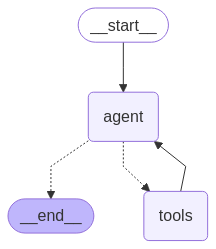

In [15]:
# Add the two tools to the list

tools = [MyEbayAPISearch(api_key='demo'), MyWeatherAPISearch()]
graph = create_react_agent(llm, tools, state_modifier=APISEARCH_PROMPT_TEXT.format(api_spec="API provided by the tool"))
graph

## Helper function to stream responses

In [16]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

## Questions and Answers

In [17]:
inputs = {"messages": [("user", QUESTION_SANDISK)]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

what is the price for SanDisk "memory cards"? give me the links please
================================== Ai Message ==================================
Tool Calls:
  apisearch (call_oHTXWkHLlHR9FXnN1wc5gozs)
 Call ID: call_oHTXWkHLlHR9FXnN1wc5gozs
  Args:
    query: SanDisk memory cards
================================= Tool Message =================================
Name: apisearch

{"request_info": {"success": true, "demo": true}, "request_parameters": {"type": "search", "ebay_domain": "ebay.com", "search_term": "SanDisk memory cards"}, "request_metadata": {"ebay_url": "https://www.ebay.com/sch/i.html?_nkw=SanDisk+memory+cards&_sacat=0&_dmd=1&_fcid=1"}, "search_results": [{"position": 1, "title": "Sandisk Micro SD Card 128GB 256GB Extreme Pro Ultra Memory Cards lot 170MB/s USA", "epid": "335700739457", "link": "https://www.ebay.com/itm/335700739457", "image": "https://i.ebayimg.com/images/g/gOMAAOSwvY1nS

================================== Ai Message ==================================

Here are some options for SanDisk memory cards available on eBay, along with their prices and links:

1. **SanDisk Micro SD Card 128GB 256GB Extreme Pro Ultra Memory Cards lot 170MB/s USA**
   - Price: $13.99
   - [View on eBay](https://www.ebay.com/itm/335700739457)
   - ![Image](https://i.ebayimg.com/images/g/gOMAAOSwvY1nSRlt/s-l500.jpg)

2. **SanDisk Micro SD Card Ultra 16GB 32GB 64GB 128GB 256GB TF SDHC/SDXC Class 10 Lot**
   - Price: $4.50
   - [View on eBay](https://www.ebay.com/itm/156319720929)
   - ![Image](https://i.ebayimg.com/images/g/kFQAAOSwiydm40su/s-l500.jpg)

3. **SanDisk 1TB Extreme PRO SDXC 4K Ultra HD Camera Memory Card**
   - Price: $69.99
   - [View on eBay](https://www.ebay.com/itm/167357606220)
   - ![Image](https://i.ebayimg.com/images/g/UQIAAOSw3ABnyM1q/s-l140.jpg)

4. **LOT 10x SanDisk Extreme PLUS 32GB SD USH-I Memory Card**
   - Price: $44.99
   - [View on eBay](https://www.eb

In [18]:
inputs = {"messages": [("user", QUESTION_WEATHER)]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Che tempo fa a Chiavari?
================================== Ai Message ==================================
Tool Calls:
  weathersearch (call_gZvbCqMozsqccxXifXL7tqvW)
 Call ID: call_gZvbCqMozsqccxXifXL7tqvW
  Args:
    query: Chiavari
================================= Tool Message =================================
Name: weathersearch

{"current_condition": [{"FeelsLikeC": "15", "FeelsLikeF": "60", "cloudcover": "0", "humidity": "82", "localObsDateTime": "2025-05-12 04:09 PM", "observation_time": "02:09 PM", "precipInches": "0.0", "precipMM": "0.2", "pressure": "1012", "pressureInches": "30", "temp_C": "15", "temp_F": "60", "uvIndex": "4", "visibility": "10", "visibilityMiles": "6", "weatherCode": "353", "weatherDesc": [{"value": "Light rain shower"}], "weatherIconUrl": [{"value": ""}], "winddir16Point": "SSW", "winddirDegree": "195", "windspeedKmph": "6", "windspeedMiles": "4"}], "nearest_area": [{"areaNam

================================== Ai Message ==================================

Attualmente a Chiavari il tempo è caratterizzato da una leggera pioggia con una temperatura di 15°C (60°F). L'umidità è all'82% e la copertura nuvolosa è assente, il che suggerisce che le precipitazioni sono probabilmente isolate. Il vento soffia da sud-sud-ovest a una velocità di 6 km/h (4 mph). La pressione atmosferica è di 1012 hPa.

Ecco un riassunto delle condizioni attuali:

- **Condizione Meteo**: Leggera pioggia
- **Temperatura**: 15°C (60°F)
- **Sensazione Termica**: 15°C (60°F)
- **Umidità**: 82%
- **Copertura Nuvolosa**: 0%
- **Vento**: SSW a 6 km/h (4 mph)
- **Visibilità**: 10 km (6 miglia)

Se hai bisogno di ulteriori dettagli o previsioni per i prossimi giorni, fammi sapere!


# Summary

In this notebook, we learned about how to create very smart API agents for simple or complex APIs that use Swagger or OpenAPI specifications.
We see, again, that the key to success is to use: Agents with Expert tools + GPT-4 + good prompts.

As homework, try to create a shopping assistant for Etsy e-commerce site using the following API spec: (you will need to register for free and create an API-Key)

- https://developers.etsy.com/documentation/
- https://www.etsy.com/openapi/generated/oas/3.0.0.json

# NEXT

The Next Notebook will guide you on how to add vision and audio to our engine.